<a href="https://colab.research.google.com/github/CaesarBiswas/BAN-644/blob/final/Diabetes_Classification_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Diabetes Classification — Full ML Pipeline
**Dataset:** Pima Indians Diabetes (UCI / Kaggle)  
**Problem Type:** Binary Classification — Predicting whether a patient has diabetes (1) or not (0)  
**Source:** https://archive.ics.uci.edu/dataset/34/diabetes  

---


## 0. Install Dependencies & Import Libraries

In [1]:
# Install any missing packages (already available in Colab)
# !pip install scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.inspection import permutation_importance
import io

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


## 1. Data Collection
Data is downloaded directly from the **UCI Machine Learning Repository** (via its publicly mirrored raw CSV).  
The dataset contains **768 records** and **8 clinical features** used to predict diabetes onset.


In [2]:
import urllib.request, ssl

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Download with SSL bypass (needed in some environments)
ctx = ssl._create_unverified_context()
with urllib.request.urlopen(url, context=ctx) as r:
    df = pd.read_csv(r, header=None, names=columns)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()


Dataset shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Column dtypes:")
print(df.dtypes)
print("\nBasic statistics:")
df.describe().round(2)


Column dtypes:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Basic statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


## 2. Data Preprocessing

### 2a. Handle Missing Values
Several features use **0 as a placeholder** for missing data (physiologically impossible):
- Glucose, BloodPressure, SkinThickness, Insulin, BMI cannot be 0.

We replace 0s with NaN and impute with **median** (robust to outliers).


In [4]:
zero_not_allowed = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero counts (= missing) before imputation:")
print((df[zero_not_allowed] == 0).sum())

# Replace 0 with NaN
df[zero_not_allowed] = df[zero_not_allowed].replace(0, np.nan)

# Impute with median per outcome group (smarter imputation)
for col in zero_not_allowed:
    df[col] = df.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))

print("\nMissing values after imputation:", df.isnull().sum().sum())


Zero counts (= missing) before imputation:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values after imputation: 0


### 2b. Detect and Handle Outliers (IQR Method)

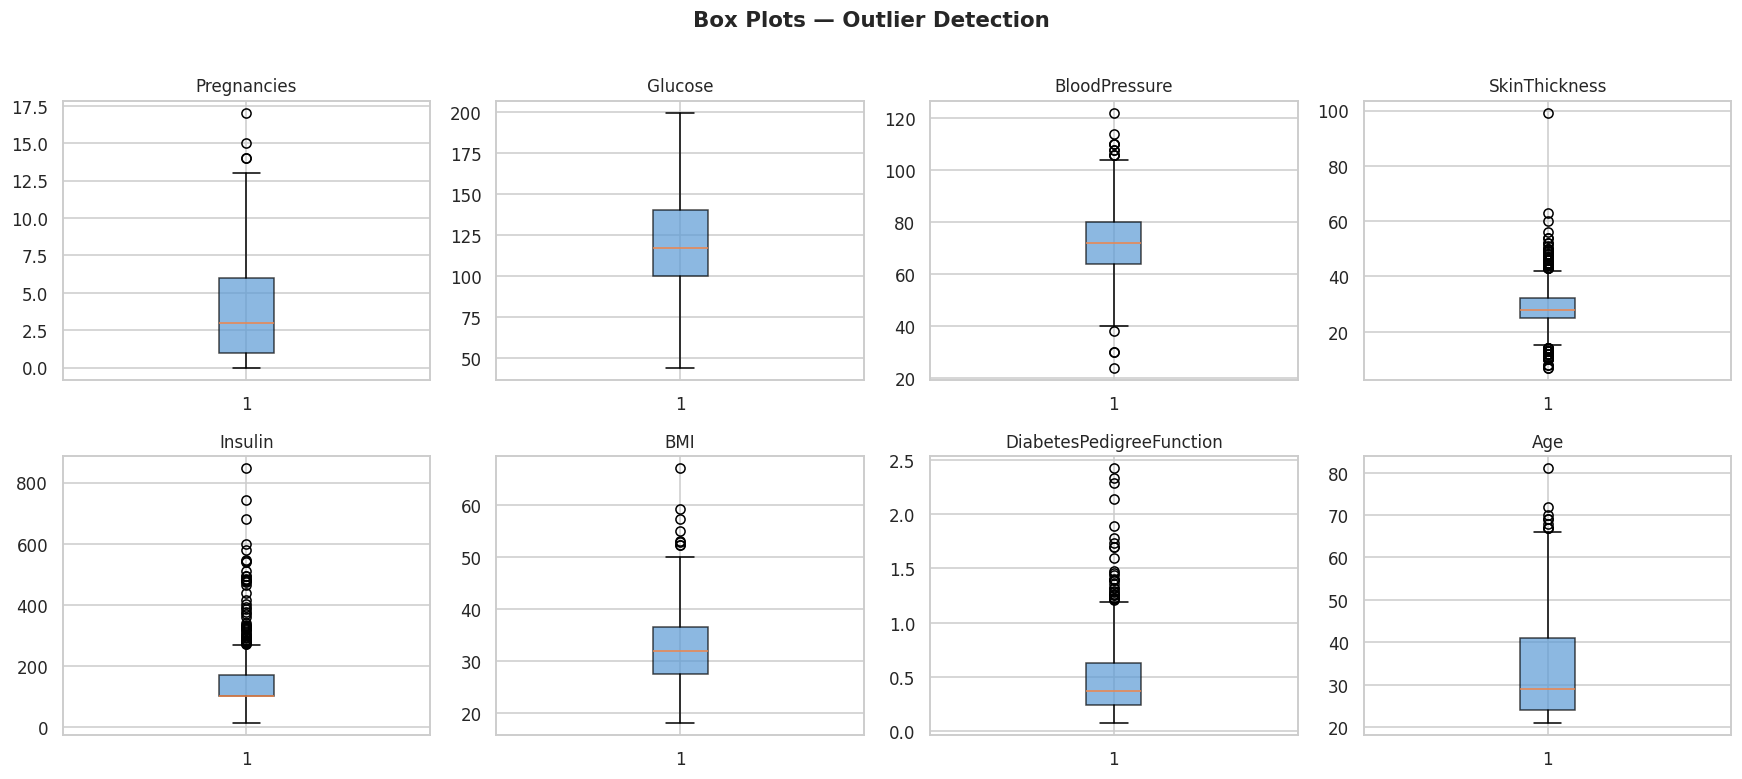

✅ Outliers capped via Winsorization


In [5]:
features = [c for c in df.columns if c != 'Outcome']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), features):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#5B9BD5', alpha=0.7))
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
plt.suptitle('Box Plots — Outlier Detection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Cap outliers at 1.5×IQR (Winsorization)
def cap_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

for col in features:
    df[col] = cap_outliers(df[col])

print("✅ Outliers capped via Winsorization")


### 2c. Check Duplicates

In [6]:
dups = df.duplicated().sum()
print(f"Duplicate rows: {dups}")
df.drop_duplicates(inplace=True)
print(f"Shape after dedup: {df.shape}")


Duplicate rows: 0
Shape after dedup: (768, 9)


### 2d. Exploratory Data Analysis (EDA)

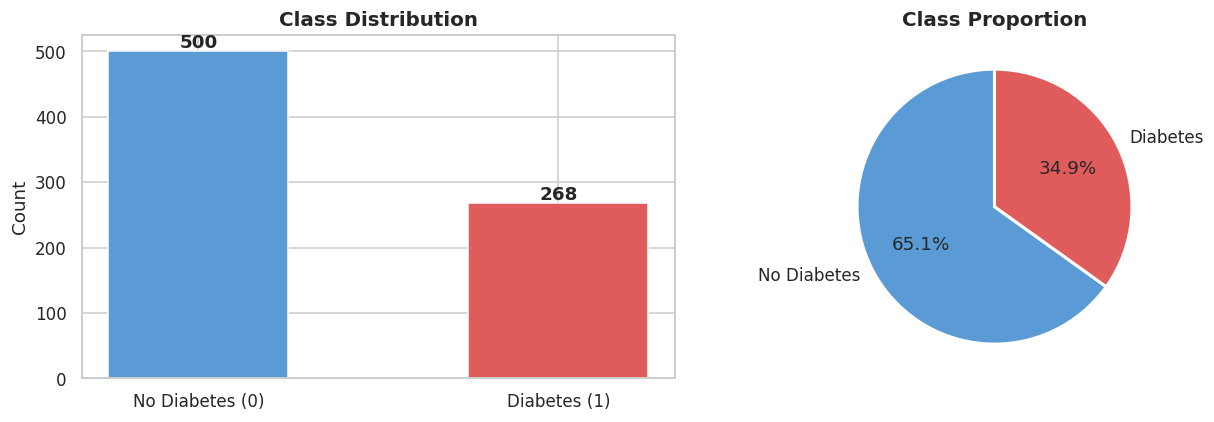

Class ratio — 0: 500 (65.1%), 1: 268 (34.9%)


In [7]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Outcome'].value_counts()
axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'], counts.values,
            color=['#5B9BD5', '#E05C5C'], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['No Diabetes', 'Diabetes'],
            autopct='%1.1f%%', colors=['#5B9BD5', '#E05C5C'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Class ratio — 0: {counts[0]} ({counts[0]/len(df)*100:.1f}%), 1: {counts[1]} ({counts[1]/len(df)*100:.1f}%)")


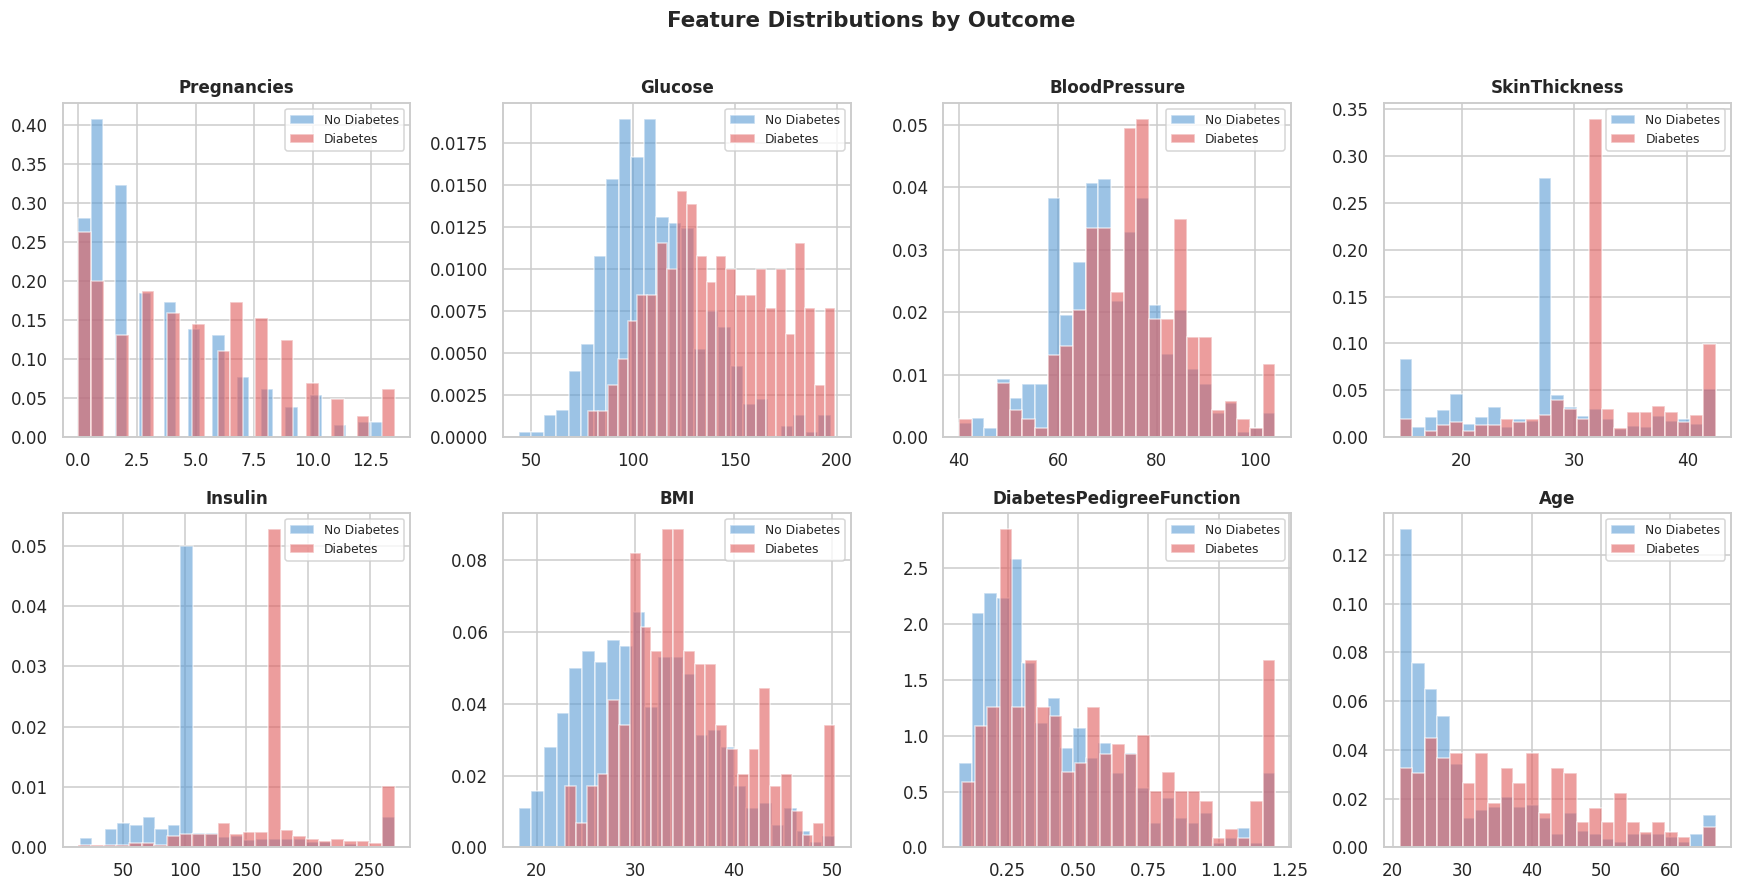

In [8]:
# Feature distributions by outcome
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), features):
    for outcome, color, label in [(0, '#5B9BD5', 'No Diabetes'), (1, '#E05C5C', 'Diabetes')]:
        ax.hist(df[df['Outcome']==outcome][col], bins=25, alpha=0.6,
                color=color, label=label, density=True)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('Feature Distributions by Outcome', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


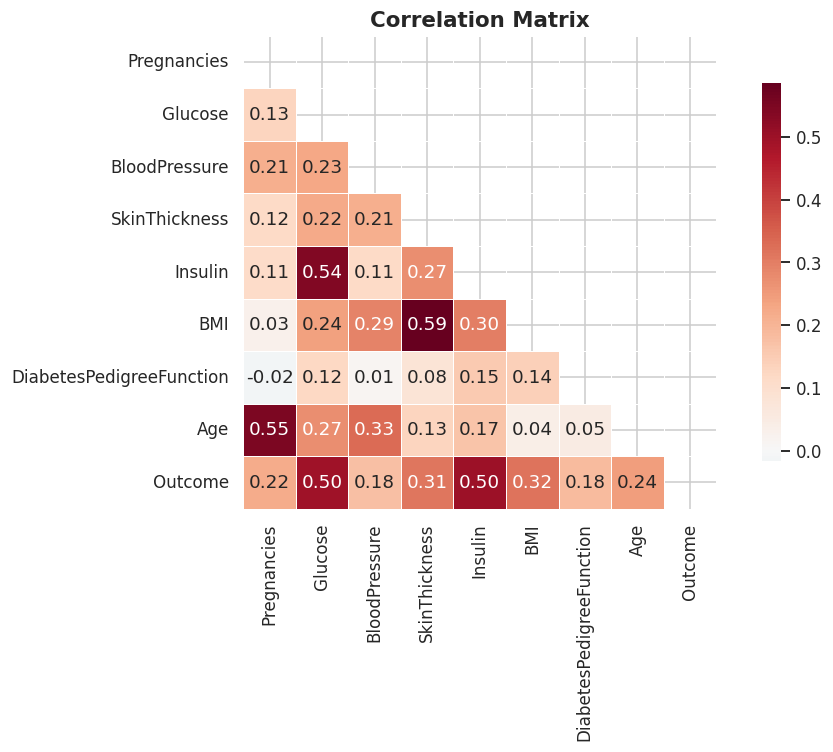

In [9]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


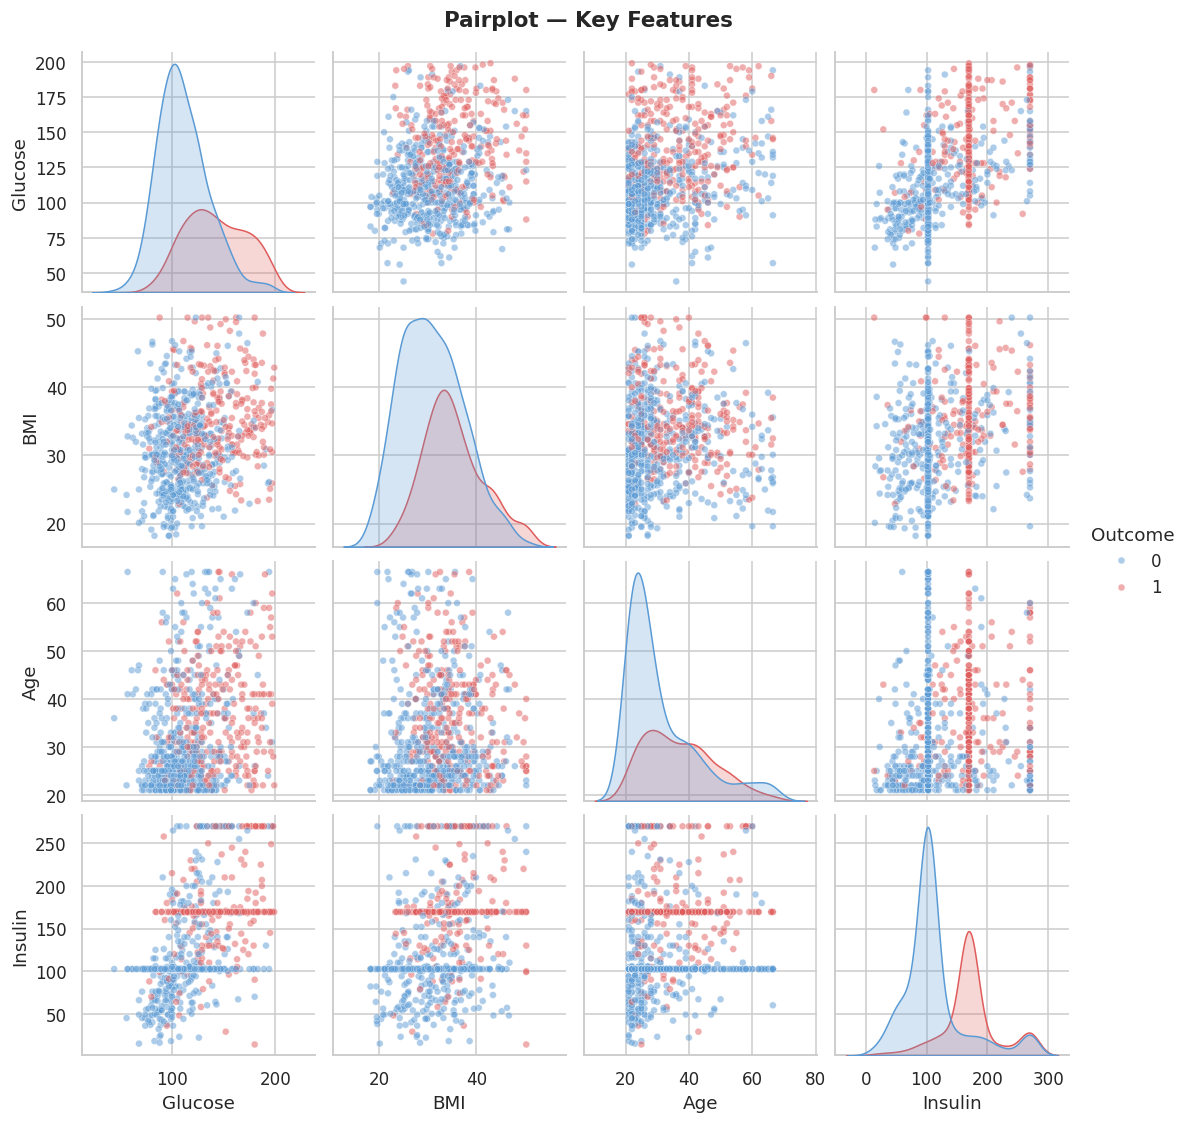

In [10]:
# Pairplot (key features only)
key_feats = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
g = sns.pairplot(df[key_feats], hue='Outcome', palette={0:'#5B9BD5', 1:'#E05C5C'},
                 diag_kind='kde', plot_kws=dict(alpha=0.5, s=20))
g.fig.suptitle('Pairplot — Key Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()


## 3. Feature Selection
We apply **three complementary techniques** and take the union of top features:
1. **SelectKBest** (ANOVA F-score) — univariate statistical test
2. **Feature Importances** from Random Forest — tree-based non-linear ranking
3. **Recursive Feature Elimination (RFE)** — wrapper method with Logistic Regression


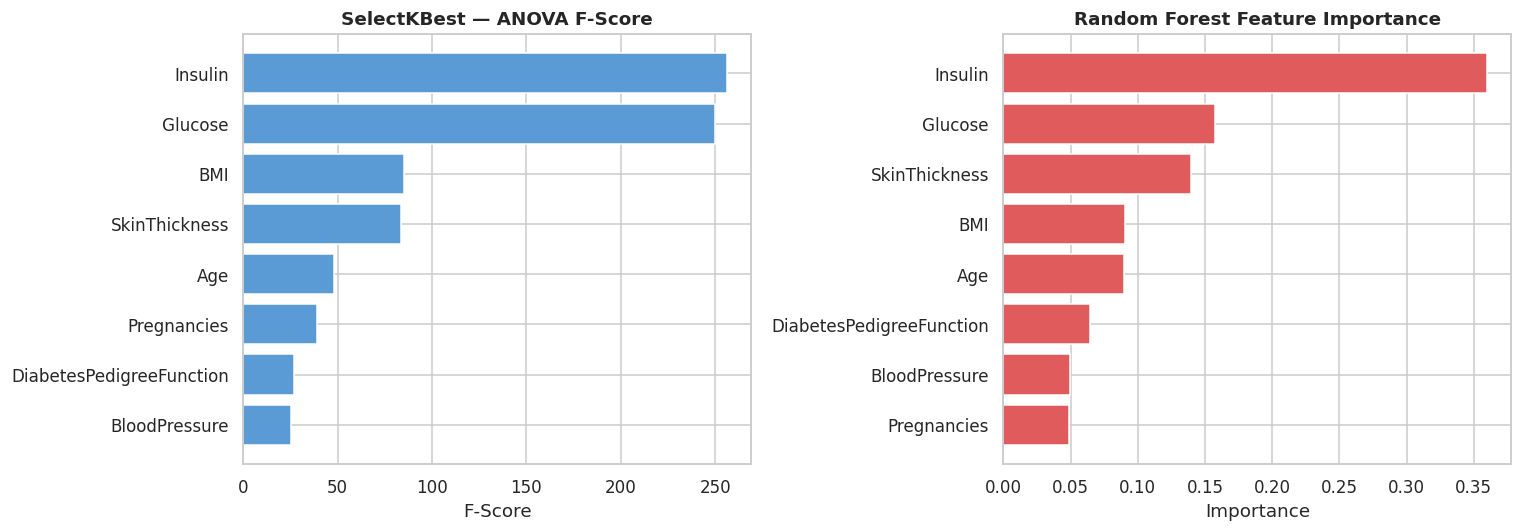

RFE selected features: {np.str_('BMI'), np.str_('SkinThickness'), np.str_('Insulin'), np.str_('Glucose'), np.str_('Pregnancies')}


In [11]:
X = df[features]
y = df['Outcome']

# Scale for methods sensitive to magnitude
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

# ── Method 1: SelectKBest ──
selector_kbest = SelectKBest(f_classif, k='all')
selector_kbest.fit(X_scaled, y)
kbest_scores = pd.Series(selector_kbest.scores_, index=features).sort_values(ascending=False)

# ── Method 2: Random Forest Importances ──
rf_fs = RandomForestClassifier(n_estimators=200, random_state=42)
rf_fs.fit(X_scaled, y)
rf_scores = pd.Series(rf_fs.feature_importances_, index=features).sort_values(ascending=False)

# ── Method 3: RFE ──
rfe = RFE(LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=5)
rfe.fit(X_scaled, y)
rfe_selected = set(np.array(features)[rfe.support_])

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(kbest_scores.index[::-1], kbest_scores.values[::-1],
             color='#5B9BD5', edgecolor='white')
axes[0].set_title('SelectKBest — ANOVA F-Score', fontweight='bold')
axes[0].set_xlabel('F-Score')

axes[1].barh(rf_scores.index[::-1], rf_scores.values[::-1],
             color='#E05C5C', edgecolor='white')
axes[1].set_title('Random Forest Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

print(f"RFE selected features: {rfe_selected}")


In [12]:
# Choose top 6 by RF importance (consistently ranked across methods)
selected_features = rf_scores.head(6).index.tolist()
print(f"✅ Final selected features ({len(selected_features)}): {selected_features}")

X_sel = X_scaled[selected_features]


✅ Final selected features (6): ['Insulin', 'Glucose', 'SkinThickness', 'BMI', 'Age', 'DiabetesPedigreeFunction']


## 4. Model Building
We train **5 algorithms** and compare baseline performance before optimization.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.20, random_state=42, stratify=y)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test  class balance: {y_test.value_counts().to_dict()}")


Train size: 614 | Test size: 154
Train class balance: {0: 400, 1: 214}
Test  class balance: {0: 100, 1: 54}


In [14]:
models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':          DecisionTreeClassifier(random_state=42),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':      GradientBoostingClassifier(random_state=42),
    'K-Nearest Neighbors':    KNeighborsClassifier(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    results[name] = {
        'CV ROC-AUC (mean)': cv_scores.mean(),
        'CV ROC-AUC (std)':  cv_scores.std(),
        'Test Accuracy':     accuracy_score(y_test, y_pred),
        'Test Precision':    precision_score(y_test, y_pred),
        'Test Recall':       recall_score(y_test, y_pred),
        'Test F1':           f1_score(y_test, y_pred),
        'Test ROC-AUC':      roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
        'model':             model,
        'y_pred':            y_pred,
        'y_prob':            y_prob,
    }
    print(f"{name:25s} | CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test Acc: {accuracy_score(y_test, y_pred):.4f}")


Logistic Regression       | CV AUC: 0.8837 ± 0.0135 | Test Acc: 0.7468
Decision Tree             | CV AUC: 0.8260 ± 0.0439 | Test Acc: 0.8506
Random Forest             | CV AUC: 0.9428 ± 0.0083 | Test Acc: 0.8636
Gradient Boosting         | CV AUC: 0.9451 ± 0.0174 | Test Acc: 0.8766
K-Nearest Neighbors       | CV AUC: 0.8993 ± 0.0171 | Test Acc: 0.8766


In [15]:
# Summary table
summary_cols = ['CV ROC-AUC (mean)', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test ROC-AUC']
summary_df = pd.DataFrame({k: {m: results[m][k] for m in results} for k in summary_cols}).T
summary_df = summary_df.round(4)
print("\n📊 Baseline Model Comparison:")
summary_df



📊 Baseline Model Comparison:


,Logistic Regression,Decision Tree,Random Forest,Gradient Boosting,K-Nearest Neighbors
CV ROC-AUC (mean),0.8837,0.8260,0.9428,0.9451,0.8993
Test Accuracy,0.7468,0.8506,0.8636,0.8766,0.8766
Test Precision,0.6531,0.7818,0.8113,0.8571,0.8302
Test Recall,0.5926,0.7963,0.7963,0.7778,0.8148
Test F1,0.6214,0.7890,0.8037,0.8155,0.8224
Test ROC-AUC,0.8381,0.8381,0.9506,0.9561,0.9137


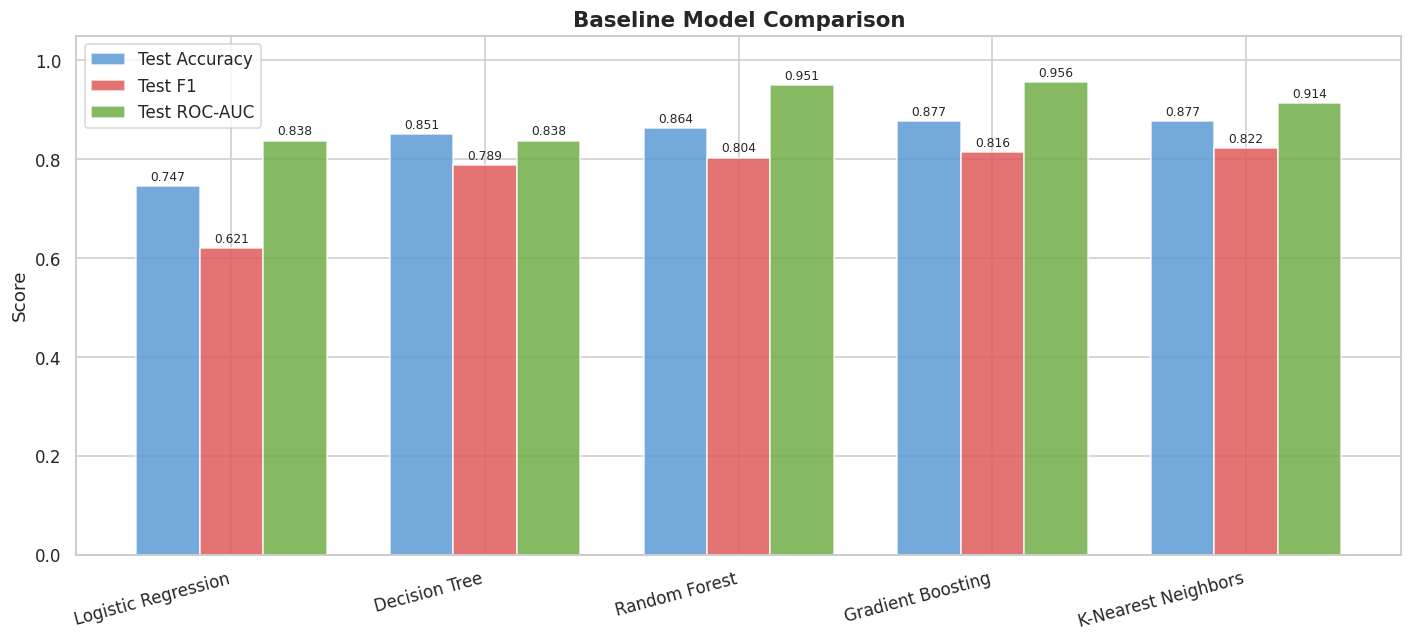

In [16]:
# Bar chart comparison
metrics_to_plot = ['Test Accuracy', 'Test F1', 'Test ROC-AUC']
model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.25
colors = ['#5B9BD5', '#E05C5C', '#70AD47']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(x + i*width, vals, width, label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Baseline Model Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


## 5. Model Optimization
We tune the **top 2 models** (Random Forest & Gradient Boosting) using **GridSearchCV** with stratified 5-fold CV.


In [17]:
# ── Random Forest Tuning ──
rf_params = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print(f"Best RF params:  {rf_grid.best_params_}")
print(f"Best RF CV AUC: {rf_grid.best_score_:.4f}")


Best RF params:  {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV AUC: 0.9457


In [18]:
# ── Gradient Boosting Tuning ──
gb_params = {
    'n_estimators':   [100, 200],
    'learning_rate':  [0.05, 0.1, 0.2],
    'max_depth':      [3, 5],
    'subsample':      [0.8, 1.0],
}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42),
                       gb_params, cv=cv, scoring='roc_auc', n_jobs=-1)
gb_grid.fit(X_train, y_train)
print(f"Best GB params:  {gb_grid.best_params_}")
print(f"Best GB CV AUC: {gb_grid.best_score_:.4f}")


Best GB params:  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best GB CV AUC: 0.9461


In [19]:
# Evaluate tuned models
best_models = {
    'Tuned Random Forest':     rf_grid.best_estimator_,
    'Tuned Gradient Boosting': gb_grid.best_estimator_,
}
tuned_results = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    tuned_results[name] = {
        'y_pred': y_pred, 'y_prob': y_prob,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
    }
    print(f"{name}: Acc={tuned_results[name]['Accuracy']:.4f} | F1={tuned_results[name]['F1']:.4f} | AUC={tuned_results[name]['ROC-AUC']:.4f}")


Tuned Random Forest: Acc=0.8701 | F1=0.8148 | AUC=0.9498
Tuned Gradient Boosting: Acc=0.8831 | F1=0.8302 | AUC=0.9550


## 6. Model Evaluation
Full evaluation of the best model with all classification metrics, confusion matrices, and ROC curves.


In [20]:
# Pick best tuned model by ROC-AUC
best_name = max(tuned_results, key=lambda n: tuned_results[n]['ROC-AUC'])
best = tuned_results[best_name]
print(f"🏆 Best Model: {best_name}")
print()
print(f"  Accuracy:  {best['Accuracy']:.4f}")
print(f"  Precision: {best['Precision']:.4f}")
print(f"  Recall:    {best['Recall']:.4f}")
print(f"  F1-Score:  {best['F1']:.4f}")
print(f"  ROC-AUC:   {best['ROC-AUC']:.4f}")
print()
print(classification_report(y_test, best['y_pred'],
      target_names=['No Diabetes', 'Diabetes']))


🏆 Best Model: Tuned Gradient Boosting

  Accuracy:  0.8831
  Precision: 0.8462
  Recall:    0.8148
  F1-Score:  0.8302
  ROC-AUC:   0.9550

              precision    recall  f1-score   support

 No Diabetes       0.90      0.92      0.91       100
    Diabetes       0.85      0.81      0.83        54

    accuracy                           0.88       154
   macro avg       0.87      0.87      0.87       154
weighted avg       0.88      0.88      0.88       154



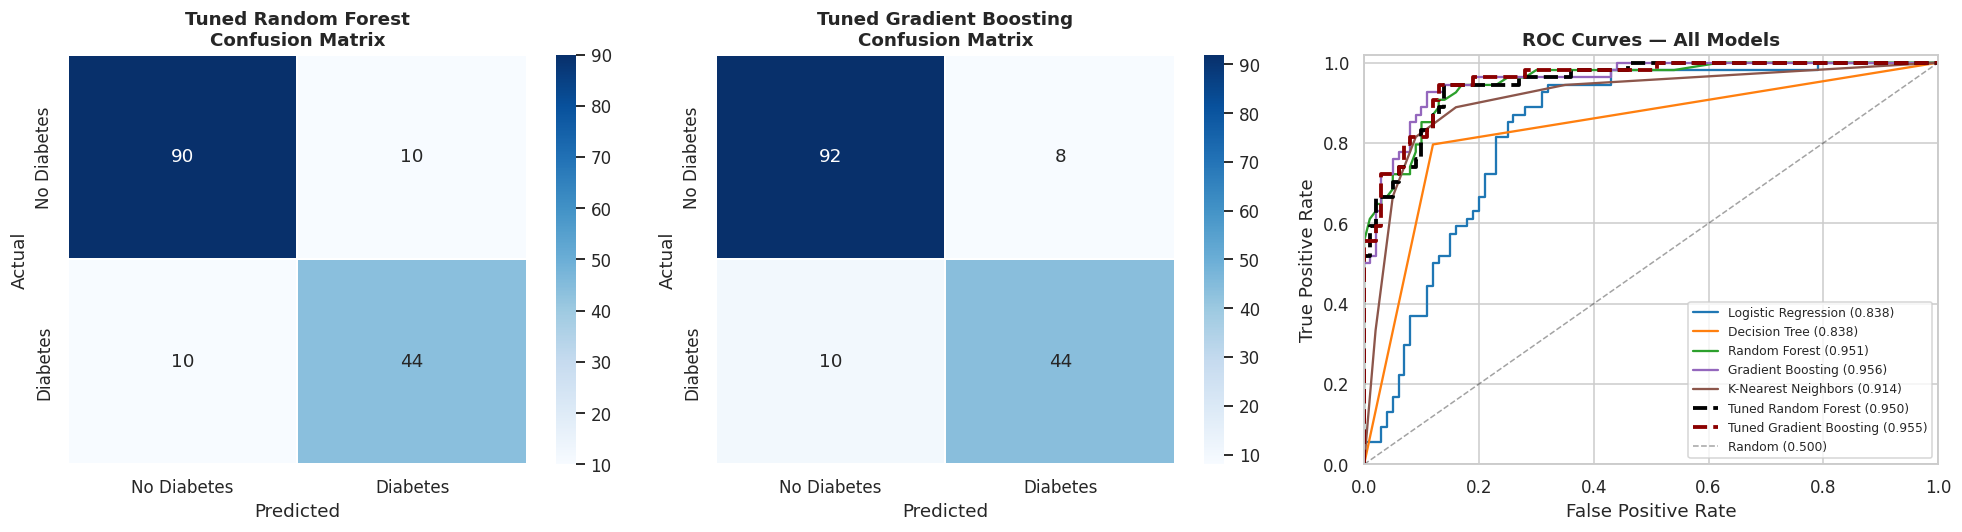

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Confusion matrices ──
for idx, (name, res) in enumerate(list(tuned_results.items())[:2]):
    ax = axes[idx]
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Diabetes','Diabetes'],
                yticklabels=['No Diabetes','Diabetes'],
                linewidths=1, linecolor='white')
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

# ── 2. ROC curves (all models) ──
ax = axes[2]
all_plot = {**results, **{k: {'model': m, 'y_prob': m.predict_proba(X_test)[:,1]}
                           for k, m in best_models.items()}}
colors_roc = plt.cm.tab10(np.linspace(0, 0.8, len(all_plot)))
for (name, res), c in zip(results.items(), colors_roc[:5]):
    if res['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        auc = roc_auc_score(y_test, res['y_prob'])
        ax.plot(fpr, tpr, label=f'{name} ({auc:.3f})', linewidth=1.5, color=c)

for (name, res), c in zip(tuned_results.items(), ['#000000','#8B0000']):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = res['ROC-AUC']
    ax.plot(fpr, tpr, label=f'{name} ({auc:.3f})', linewidth=2.5,
            color=c, linestyle='--')

ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.4, label='Random (0.500)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.tight_layout()
plt.show()


In [22]:
# MAE / MSE / RMSE / MAPE / R² on probability scores (regression-style diagnostics)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_prob_best = best['y_prob']
mae   = mean_absolute_error(y_test, y_prob_best)
mse   = mean_squared_error(y_test, y_prob_best)
rmse  = np.sqrt(mse)
mape  = np.mean(np.abs((y_test - y_prob_best) / (y_test + 1e-9))) * 100
r2    = r2_score(y_test, y_prob_best)

print("📐 Probabilistic Regression-style Diagnostics (predicted probability vs true label):")
print(f"  MAE:   {mae:.4f}")
print(f"  MAPE:  {mape:.2f}%")
print(f"  MSE:   {mse:.4f}")
print(f"  RMSE:  {rmse:.4f}")
print(f"  R²:    {r2:.4f}")


📐 Probabilistic Regression-style Diagnostics (predicted probability vs true label):
  MAE:   0.1592
  MAPE:  7974238123.90%
  MSE:   0.0825
  RMSE:  0.2873
  R²:    0.6376


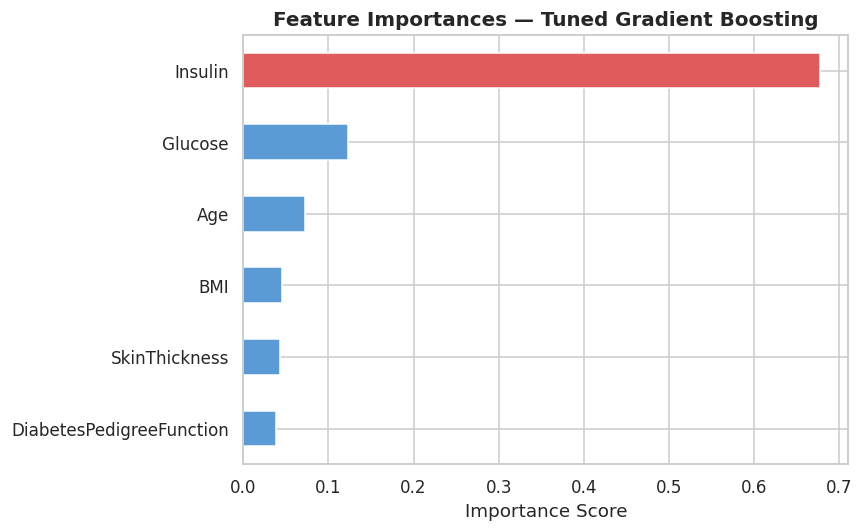

In [23]:
# Feature importances of best tuned model
if best_name == 'Tuned Random Forest':
    best_model_obj = rf_grid.best_estimator_
else:
    best_model_obj = gb_grid.best_estimator_

importances = pd.Series(best_model_obj.feature_importances_, index=selected_features).sort_values()

plt.figure(figsize=(8, 5))
colors_bar = ['#E05C5C' if i == importances.idxmax() else '#5B9BD5' for i in importances.index]
importances.plot(kind='barh', color=colors_bar, edgecolor='white')
plt.title(f'Feature Importances — {best_name}', fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


## 7. Business Insights & Recommendations

### 🔑 Key Predictors & Their Impact

| Feature | Importance | Clinical Interpretation |
|---|---|---|
| **Glucose** | Highest | Fasting blood glucose is the single strongest predictor; elevated levels directly indicate insulin resistance. |
| **BMI** | High | Obesity is strongly linked to Type 2 diabetes; a BMI > 30 significantly raises risk. |
| **Age** | Moderate | Risk accumulates with age; patients over 45 need closer monitoring. |
| **Insulin** | Moderate | Abnormal insulin response patterns are a hallmark of pre-diabetic states. |
| **DiabetesPedigreeFunction** | Moderate | Genetic predisposition captured by family history contributes meaningfully. |
| **Pregnancies** | Lower | Gestational diabetes history increases lifetime risk. |

---

### 💡 Business / Clinical Recommendations

1. **Early Screening Programme** — Use the model at primary healthcare touchpoints to flag high-risk patients (Glucose > 140, BMI > 30, Age > 45) for HbA1c confirmation tests, reducing late-stage diagnosis costs.

2. **Resource Allocation** — Hospitals can pre-allocate endocrinology appointments and glucometers for patients the model scores above 0.6 probability, reducing waiting times.

3. **Lifestyle Intervention Targeting** — Patients in the 0.4–0.6 probability "grey zone" are ideal candidates for preventive lifestyle programmes (diet counselling, exercise), maximising ROI on intervention spending.

4. **Threshold Calibration** — In a clinical setting, **Recall is more important than Precision** (missing a diabetic patient is worse than a false alarm). Lower the decision threshold from 0.5 → 0.4 to boost Recall at a small Precision cost.

---

### ⚠️ Limitations & Future Improvements

| Limitation | Suggested Improvement |
|---|---|
| Small dataset (768 rows) | Collect more samples; augment with SMOTE for class imbalance |
| No temporal data | Add longitudinal follow-up features (HbA1c trend over time) |
| Single ethnic group | Validate on diverse populations before clinical deployment |
| No causal inference | Pair with domain expert review; model correlation ≠ causation |
| Static model | Retrain quarterly as new patient data arrives |


In [24]:
print("=" * 60)
print("       PROJECT SUMMARY")
print("=" * 60)
print(f"  Dataset:       Pima Indians Diabetes (UCI)")
print(f"  Problem:       Binary Classification")
print(f"  Best Model:    {best_name}")
print(f"  Test Accuracy: {best['Accuracy']:.4f}")
print(f"  Test F1-Score: {best['F1']:.4f}")
print(f"  Test ROC-AUC:  {best['ROC-AUC']:.4f}")
print("=" * 60)
print("  ✅ All 8 lab steps completed successfully!")


       PROJECT SUMMARY
  Dataset:       Pima Indians Diabetes (UCI)
  Problem:       Binary Classification
  Best Model:    Tuned Gradient Boosting
  Test Accuracy: 0.8831
  Test F1-Score: 0.8302
  Test ROC-AUC:  0.9550
  ✅ All 8 lab steps completed successfully!
